In [2]:
!wget -O sample_image.tif https://github.com/rasterio/rasterio/raw/main/tests/data/RGB.byte.tif

--2026-09-22 02:18:50--  https://github.com/rasterio/rasterio/raw/main/tests/data/RGB.byte.tif
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/rasterio/rasterio/main/tests/data/RGB.byte.tif [following]
--2026-09-22 02:18:50--  https://raw.githubusercontent.com/rasterio/rasterio/main/tests/data/RGB.byte.tif
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1745956 (1.7M) [image/tiff]
Saving to: ‘sample_image.tif’

sample_image.tif    100%[===================>]   1.67M  --.-KB/s    in 0.01s   

2026-09-22 02:18:51 (133 MB/s) - ‘sample_image.tif’ saved [1745956/1745956]



In [3]:
import rasterio
import numpy as np

with rasterio.open('sample_image.tif') as src:
    image = src.read()  # shape: (bands, height, width)
    profile = src.profile

print(image.shape)

(3, 718, 791)


In [4]:
bands, height, width = image.shape
X = image.reshape(bands, -1).T  # each row = one pixel, each column = one band
print(X.shape)

(567938, 3)


In [5]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X)

clustered_image = clusters.reshape(height, width)

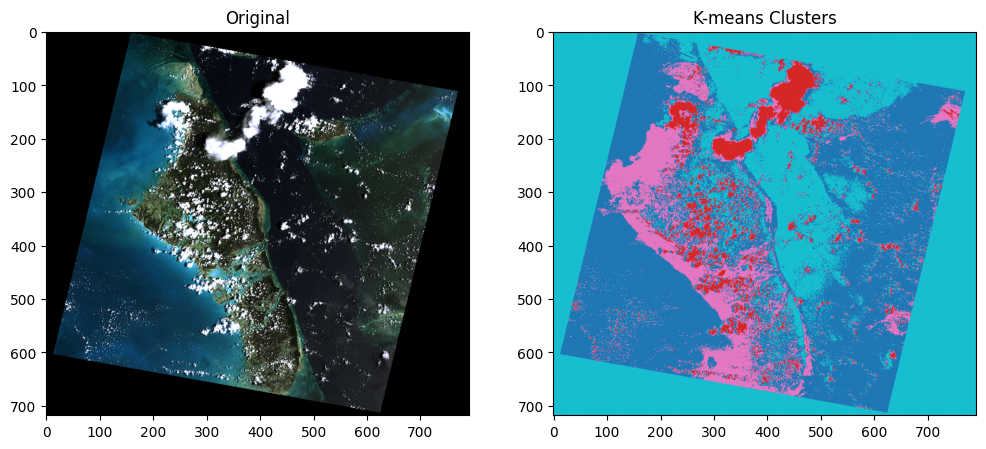

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(12,6))
ax[0].imshow(np.transpose(image[:3], (1,2,0)))
ax[0].set_title('Original')
ax[1].imshow(clustered_image, cmap='tab10')
ax[1].set_title('K-means Clusters')
plt.show()